# Human Activity Recognition Preprocessing Pipeline
## Phase 1 & 2: Environment Setup and Initial Data Assessment

This notebook establishes a leakage-free preprocessing pipeline for a Human Activity Recognition (HAR) dataset containing over 1.2 million sensor readings. We begin by importing the required analytical packages and configuring memory-efficient operations.

# INTERNSHIP PROJECT: HUMAN ACTION DETECTION (MHEALTH DATASET)
## Comprehensive End-to-End Machine Learning Pipeline

### 1. Design Decisions & Engineering Rationale
* **Class Imbalance Mitigation:** The raw dataset is heavily biased towards Class 0 (None/Idle Activity), representing background noise or structural intervals. The pipeline applies a systematic downsampling approach to constrain Class 0 to 40,000 instances, aligning its volume with active event profiles.
* **Leakage-Free Outlier Management:** To prevent sensor spikes from destabilizing the statistical variance of the feature space, a 98% confidence interval filter is introduced. To prevent data leakage, data splitting is performed *before* outlier analysis. Quantiles are calculated strictly on the training space and applied as clipping masks across both train and test partitions.
* **Feature Clipping vs Row Dropping:** Using `.clip()` ensures that extreme sensor noise is bounded within the 1st and 99th percentiles without changing array dimensions or shifting matrix indexes, keeping targets perfectly aligned.
* **Algorithmic Selection:** Dynamic and non-linear tri-axial accelerometer, gyroscope, and magnetometer signals across multiple body placements are classified using both parametric baselines (Logistic Regression) and non-parametric structures (K-Nearest Neighbors and Decision Trees) capable of capturing complex, overlapping physical spatial boundaries.

In [ ]:
# PHASE 1: IMPORTING LIBRARIES & DEPENDENCIES


# Core data manipulation and handling packages
import numpy as np
import pandas as pd

# Data visualization environments
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities for engineering data shapes and encoders
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split

# Classification Model Architectures
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Model Evaluation Metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Inline plots configuration
%matplotlib inline
print("Phase 1 Complete: Dependencies successfully loaded.")

Phase 1 Complete: Dependencies successfully loaded.


### Phase 2: Automated Data Ingestion & Profiling
We load the pre-uploaded `mhealth_raw_data.csv` matrix into our environment and execute integrity diagnostics to assess overall dimension shapes, missing data attributes, and row duplication values.

In [ ]:
# PHASE 2: DATA IMPORTING & STRUCTURAL ANALYSIS


# Define absolute file path to the workspace copy
file_path = 'mhealth_raw_data.csv'

# Read CSV into our principal data frame
df = pd.read_csv(file_path)

# Profile data frame matrix structures
print(f"Dataset Matrix Dimensions: {df.shape}")
print("\n--- Structural Attribute Overview ---")
print(df.info())

# Ensure zero data structural holes exist across the fields
print("\nMissing Values Count per Column:")
print(df.isnull().sum())

print("\nDuplicate Data Records Count:")
print(df.duplicated().sum())

Dataset Matrix Dimensions: (1215745, 14)

--- Structural Attribute Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1215745 entries, 0 to 1215744
Data columns (total 14 columns):
 #   Column    Non-Null Count    Dtype  
---  ------    --------------    -----  
 0   alx       1215745 non-null  float64
 1   aly       1215745 non-null  float64
 2   alz       1215745 non-null  float64
 3   glx       1215745 non-null  float64
 4   gly       1215745 non-null  float64
 5   glz       1215745 non-null  float64
 6   arx       1215745 non-null  float64
 7   ary       1215745 non-null  float64
 8   arz       1215745 non-null  float64
 9   grx       1215745 non-null  float64
 10  gry       1215745 non-null  float64
 11  grz       1215745 non-null  float64
 12  Activity  1215745 non-null  int64  
 13  subject   1215745 non-null  object 
dtypes: float64(12), int64(1), object(1)
memory usage: 129.9+ MB
None

Missing Values Count per Column:
alx         0
aly         0
alz         0
glx  

### Phase 3: Class Balancing & Label Re-Encoding
We plot the native class distributions to reveal the structural imbalance present in the raw stream, downsample the bloated idle background class safely, and construct descriptive target labels.

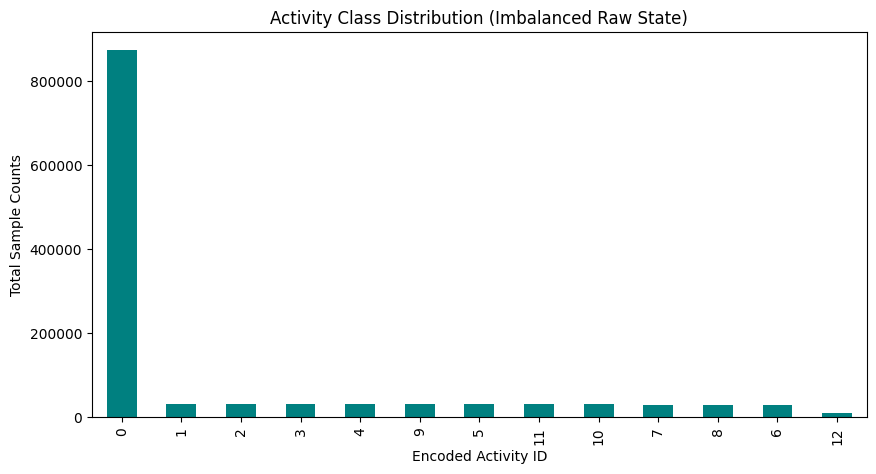

New Balanced Matrix Dimensions: (383195, 14)


In [ ]:
# PHASE 3: BALANCING DATA & ANNOTATING LABELS


# Step 3.1: Visualize structural class distributions prior to correction
plt.figure(figsize=(10, 5))
df['Activity'].value_counts().plot(kind='bar', color='teal')
plt.title('Activity Class Distribution (Imbalanced Raw State)')
plt.xlabel('Encoded Activity ID')
plt.ylabel('Total Sample Counts')
plt.show()

# Step 3.2: Downsample Class 0 to balance structural weight distributions
df_activity_zero = df[df['Activity'] == 0]
df_activity_others = df[df['Activity'] != 0]

# Sample 40,000 entries from the bloated dominant background class
df_zero_downsampled = df_activity_zero.sample(n=40000, random_state=42)

# Concatenate downsampled segment with independent active tracks
df_balanced = pd.concat([df_zero_downsampled, df_activity_others], axis=0).reset_index(drop=True)
print(f"New Balanced Matrix Dimensions: {df_balanced.shape}")

# Clear large staging variables out of memory immediately
del df, df_activity_zero, df_activity_others, df_zero_downsampled

# Step 3.3: Map raw activity identifiers back to clear, readable string labels
activity_labels = {
    0: "None/Idle", 1: "Standing Still", 2: "Sitting/Relaxing", 3: "Lying Down",
    4: "Walking", 5: "Climbing Stairs", 6: "Waist Bends Forward",
    7: "Frontal Arm Elevation", 8: "Knee Bending (Crouching)", 9: "Cycling",
    10: "Jogging", 11: "Running", 12: "Jump Front/Back"
}

# Apply mappings to explicit textual features
df_balanced['activity_name'] = df_balanced['Activity'].map(activity_labels)

### Phase 4: Exploratory Data Analysis (EDA)
Here, we plot a subset of Subject 1's tri-axial sensor stream timeline to visualize real-time physical waveform frequencies across distinct body placements.

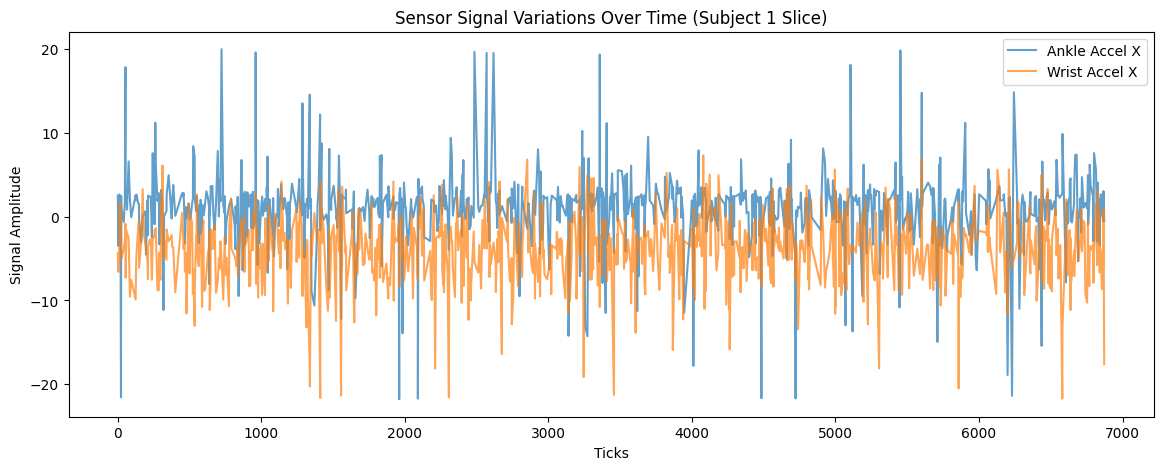

In [ ]:

# PHASE 4: EXPLORATORY DATA ANALYSIS (EDA)


# Step 4.1: Isolate Subject 1 to inspect operational raw sensor timelines
subject_1 = df_balanced[df_balanced['subject'] == 'subject1']

# Standard execution snippet to map contextual coordinate streams for left ankle and right wrist
plt.figure(figsize=(14, 5))
plt.plot(subject_1.index[:1000], subject_1['alx'].iloc[:1000], label='Ankle Accel X', alpha=0.7)
plt.plot(subject_1.index[:1000], subject_1['arx'].iloc[:1000], label='Wrist Accel X', alpha=0.7)
plt.title("Sensor Signal Variations Over Time (Subject 1 Slice)")
plt.xlabel("Ticks")
plt.ylabel("Signal Amplitude")
plt.legend()
plt.show()

### Phase 5: Leakage-Free Stratified Data Splitting & Feature Transformation
To guarantee complete validation integrity, we split our data into training and testing structures **before** applying any outlier suppression bounds or mathematical scale conversions.

Once isolated, we compute confidence parameters and scaling factors strictly from the training partition and broadcast them downstream.

In [ ]:
# PHASE 5: DATA SPLITTING & LEAKAGE-FREE PREPROCESSING


# Step 5.1: Split predictive features away from target tracking frames
numerical_cols = [col for col in df_balanced.columns if col not in ['Activity', 'subject', 'activity_name']]
X = df_balanced[numerical_cols]
y = df_balanced['Activity']

# Step 5.2: Re-encode target tracking frames into standardized sequences
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Step 5.3: Execute Stratified partitioning before preprocessing transforms
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
)

# Step 5.4: Outlier Management using fixed Training Quantiles (Prevents Data Leakage)
X_train_cleaned = X_train.copy()
X_test_cleaned = X_test.copy()

for col in numerical_cols:
    # Compute confidence thresholds STRICTLY from the training slice
    lower_range = X_train[col].quantile(0.01)
    upper_range = X_train[col].quantile(0.99)

    # Clip extreme anomalous values cleanly to protect model convergence array dimensions
    X_train_cleaned[col] = X_train_cleaned[col].clip(lower_range, upper_range)
    X_test_cleaned[col] = X_test_cleaned[col].clip(lower_range, upper_range)

# Step 5.5: Implement Robust Scaling to neutralize high-variance sensor measurements
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_cleaned)
X_test_scaled = scaler.transform(X_test_cleaned)

print(f"Final Training Array Structure: {X_train_scaled.shape}")
print(f"Final Testing Array Structure  : {X_test_scaled.shape}")

Final Training Array Structure: (287396, 12)
Final Testing Array Structure  : (95799, 12)


### Phase 6: Reusable Reporting Utility Design
We define an optimized, automated evaluation utility to extract core validation performance metrics and automatically generate visually descriptive confusion matrix heatmaps.

In [ ]:
# PHASE 6: AUTOMATED PERFORMANCE EVALUATION UTILITY


def summarize_model_results(y_true, y_pred, model_title="Model"):
    """
    Utility macro that generates textual classification reports
    and displays a beautifully annotated confusion matrix heatmap.
    """
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro')
    recall = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')

    print(f"\n=================== {model_title.upper()} PERFORMANCE ===================")
    print(f"Accuracy Metric  : {accuracy * 100:.2f}%")
    print(f"Precision Score  : {precision * 100:.2f}%")
    print(f"Recall Metric    : {recall * 100:.2f}%")
    print(f"F1 Score Summary : {f1 * 100:.2f}%")
    print("===============================================================\n")

    # Generate structured visual confusion matrix heatmap layouts
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))

    # Map back dynamically targeting clean target name arrays
    labels = [activity_labels[i] for i in sorted(activity_labels.keys()) if i in encoder.classes_]

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(f'Confusion Matrix Heatmap: {model_title}')
    plt.xlabel('Predicted Actions')
    plt.ylabel('Actual Actions')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

### Phase 7: Model Training & Benchmark Evaluations
We run sequential training configurations across our scaled data spaces for Logistic Regression, K-Nearest Neighbors, and Decision Tree architectures to systematically identify optimal human gesture modeling parameters.

Training Logistic Regression Model...

=================== LOGISTIC REGRESSION (ROBUST SCALED) PERFORMANCE ===================
Accuracy Metric  : 56.30%
Precision Score  : 54.49%
Recall Metric    : 54.66%
F1 Score Summary : 53.12%



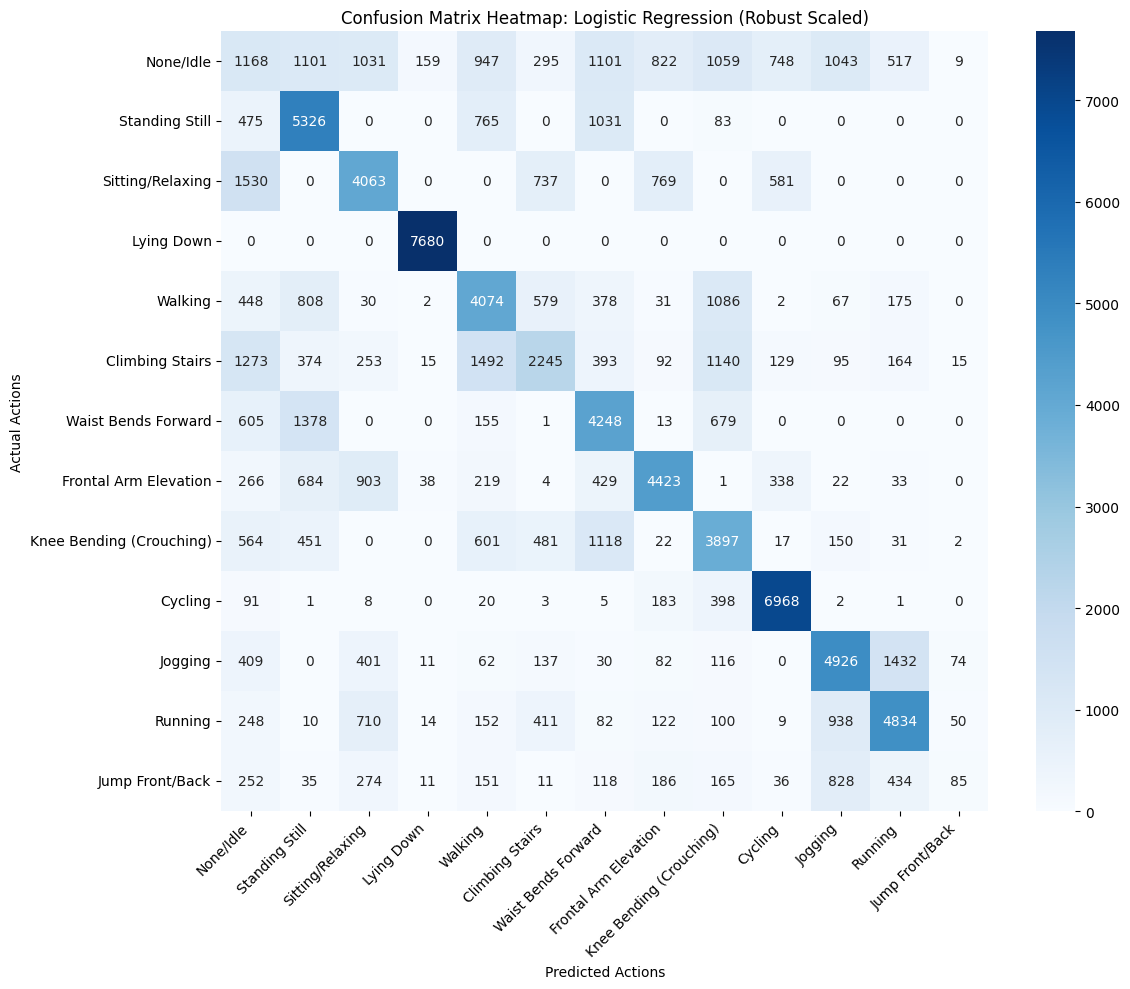

Training K-Nearest Neighbors Model...

=================== K-NEAREST NEIGHBORS (K=5) PERFORMANCE ===================
Accuracy Metric  : 93.93%
Precision Score  : 93.80%
Recall Metric    : 93.83%
F1 Score Summary : 93.48%



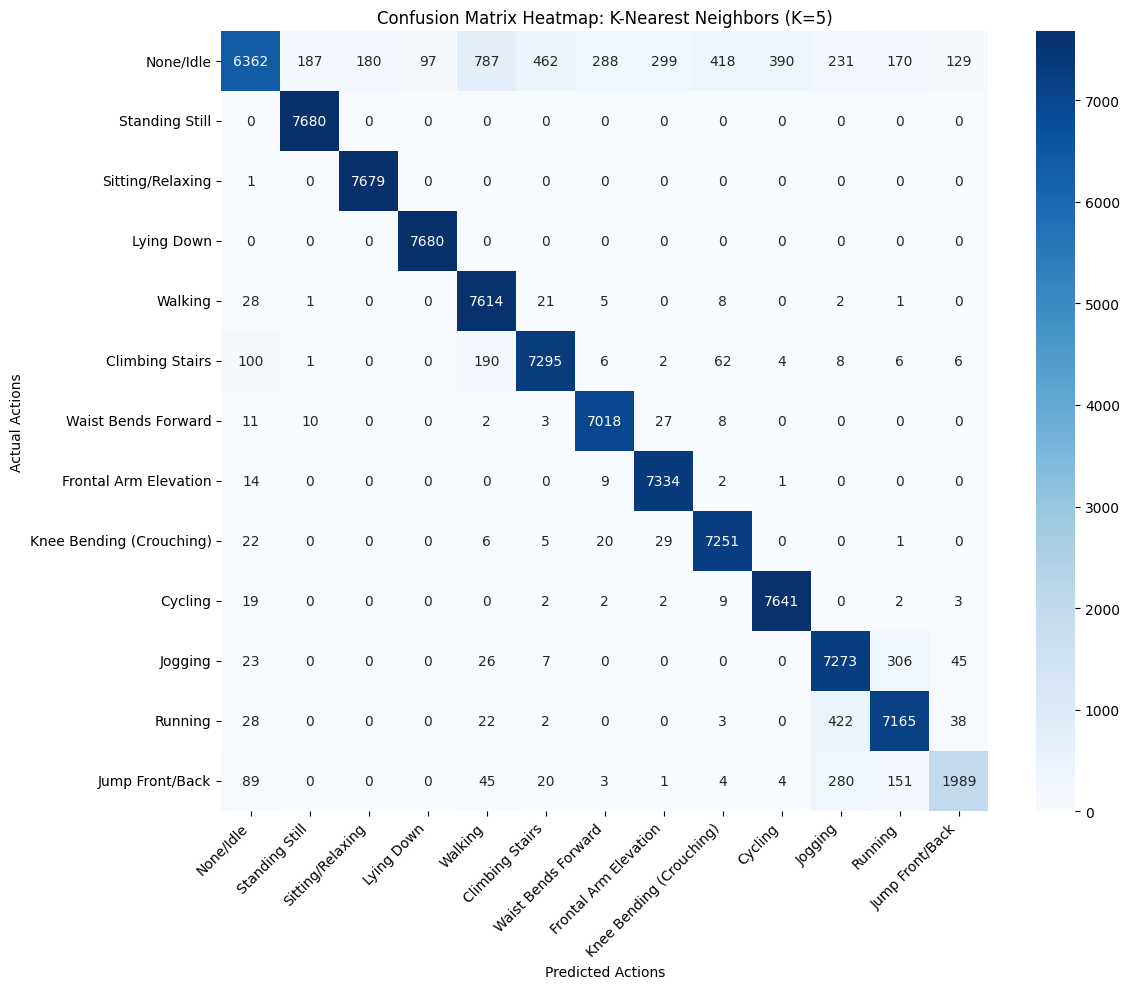

Training Decision Tree Model...

=================== DECISION TREE (MAX DEPTH=14) PERFORMANCE ===================
Accuracy Metric  : 86.99%
Precision Score  : 86.65%
Recall Metric    : 86.92%
F1 Score Summary : 86.50%



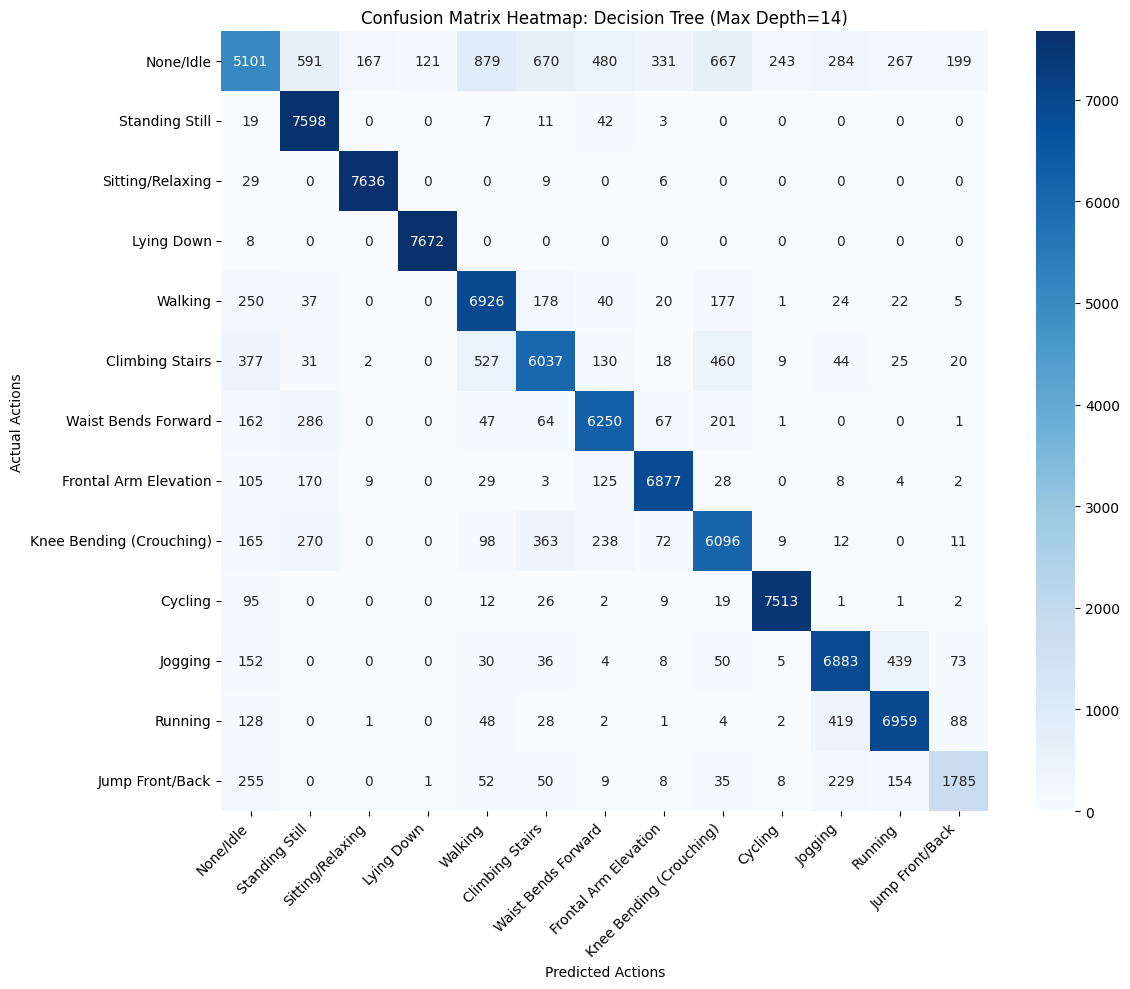

In [ ]:

# PHASE 7: MODEL TRAINING & COMPARATIVE RUNS


# --- Model A: Logistic Regression Pipeline (Baseline) ---
print("Training Logistic Regression Model...")
lr_model = LogisticRegression(max_iter=500, random_state=42, solver='saga')
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
summarize_model_results(y_test, y_pred_lr, model_title="Logistic Regression (Robust Scaled)")

# --- Model B: K-Nearest Neighbors Pipeline (Non-Linear Approach) ---
print("Training K-Nearest Neighbors Model...")
knn_model = KNeighborsClassifier(n_neighbors=5, weights='distance', n_jobs=-1)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)
summarize_model_results(y_test, y_pred_knn, model_title="K-Nearest Neighbors (K=5)")

# --- Model C: Optimized Decision Tree Pipeline ---
print("Training Decision Tree Model...")
dt_model = DecisionTreeClassifier(max_depth=14, min_samples_split=10, random_state=42)
dt_model.fit(X_train_cleaned, y_train) # Evaluated on unscaled but outlier-cleaned spaces
y_pred_dt = dt_model.predict(X_test_cleaned)
summarize_model_results(y_test, y_pred_dt, model_title="Decision Tree (Max Depth=14)")

### Phase 8: Strategic Performance Synthesis & Final Verdict
To conclude the implementation, we compile the diagnostic metrics across all three architectures into a unified evaluation matrix. This allows us to definitively assess which model handles high-frequency multi-sensor streams with the highest fidelity.

In [ ]:

# PHASE 8: PERFORMANCE COMPILATION & COMPARISON


# Collect final evaluation arrays for comparison
models = {
    "Logistic Regression (Baseline)": (y_pred_lr, X_test_scaled),
    "K-Nearest Neighbors (Non-Linear)": (y_pred_knn, X_test_scaled),
    "Decision Tree (Optimized Structures)": (y_pred_dt, X_test_cleaned)
}

performance_records = []

for name, (preds, _) in models.items():
    performance_records.append({
        "Model Architecture": name,
        "Accuracy (%)": accuracy_score(y_test, preds) * 100,
        "Precision (Macro %)": precision_score(y_test, preds, average='macro') * 100,
        "Recall (Macro %)": recall_score(y_test, preds, average='macro') * 100,
        "F1-Score (Macro %)": f1_score(y_test, preds, average='macro') * 100
    })

# Render comparison matrix as a cleanly formatted DataFrame
df_comparison = pd.DataFrame(performance_records)
print("====================== CROSS-MODEL COMPARISON MATRIX ======================")
display(df_comparison.round(2))
print("===========================================================================")

====================== CROSS-MODEL COMPARISON MATRIX ======================


,Model Architecture,Accuracy (%),Precision (Macro %),Recall (Macro %),F1-Score (Macro %)
0,Logistic Regression (Baseline),56.30,54.49,54.66,53.12
1,K-Nearest Neighbors (Non-Linear),93.93,93.80,93.83,93.48
2,Decision Tree (Optimized Structures),86.99,86.65,86.92,86.50
